<h1> Lab 2, Task 1 (Dataset - Heart Disease), Sverdlyk Ivan, FB-51mp </h1>

### Розпочнемо з відтворення результатів першої лабораторної роботи для найкращого методу (kNN)

In [1]:
# Спершу імпортую всі бібліотеки необхідні для даного завдання
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#### Завантаження, демонстрація та підготовка даних

In [2]:
# Завантажу,продемонструю та підготую дані
df = pd.read_csv('heart.csv')
print("\n First 5 rows")
print(df.head(5))
print("\n General information about DataFrame heart.csv:")
print(df.info())
print("\n Basic stats for numeric columns:")
print(df.describe())
print("\n Shape of DataFrame:")
print(df.shape)
print("\n List of Columns:")
print(df.columns)
# Іншу інформацію пропускаю, адже вона наведена в першій лабораторній роботі
# Розділяю дані на тренувальний та тестовий набір
X = df.drop('target', axis =1)
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print('\n Size of training set')
print(X_train_scaled.shape)
print('\n Size of testing set')
print(X_test_scaled.shape)


 First 5 rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

 General information about DataFrame heart.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  30

#### Використання моделі kNN на початкових даних, а також з PCA


 GridSearch for KNN (no PCA)
Best Parameters for kNN (no PCA): {'n_neighbors': np.int64(16)}
Best Cross-Validation Accuracy for kNN (no PCA): 0.83
Training time (with GridSearch) for kNN (no PCA): 0.73 seconds

Classification report for kNN (no PCA):
              precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



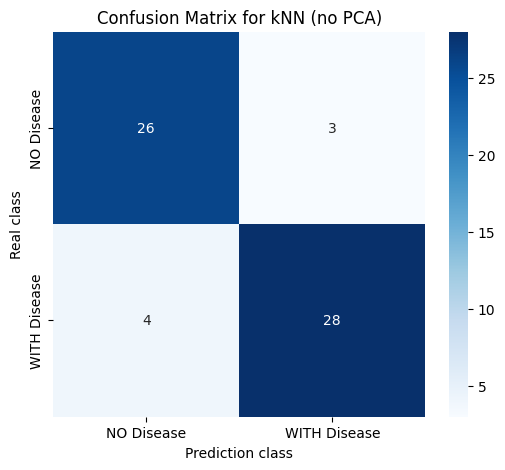


 GridSearch for KNN (PCA)
Original number of features: 13
Components after PCA: 12
Best parameters for kNN with PCA: {'n_neighbors': np.int64(20)}
Best cross-validation accuracy for kNN with PCA: 0.83
Training time (with GridSearchCV) for kNN with PCA: 0.22 seconds

Classification report for kNN (PCA):
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        29
           1       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



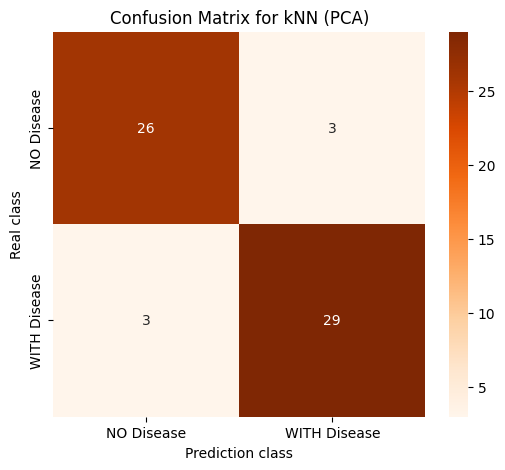

In [5]:
# GridSearch для KNN на початкових даних
print('\n GridSearch for KNN (no PCA)')
knn_parameters = {'n_neighbors': np.arange(1, 21)}
knn_grid_original = GridSearchCV(KNeighborsClassifier(), knn_parameters, cv=5, scoring='accuracy')
start_time = time.time()
knn_grid_original.fit(X_train_scaled, y_train)
training_time_original = time.time() - start_time
best_knn_original = knn_grid_original.best_estimator_
print(f"Best Parameters for kNN (no PCA): {knn_grid_original.best_params_}")
print(f"Best Cross-Validation Accuracy for kNN (no PCA): {knn_grid_original.best_score_:.2f}")
print(f"Training time (with GridSearch) for kNN (no PCA): {training_time_original:.2f} seconds")
# Класифікаційний звіт для початкових даних
print("\nClassification report for kNN (no PCA):")
y_pred_original = best_knn_original.predict(X_test_scaled)
print(classification_report(y_test, y_pred_original))
# Матриця плутанини для початкових даних
cm1 = confusion_matrix(y_test, y_pred_original)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO Disease', 'WITH Disease'],
            yticklabels=['NO Disease', 'WITH Disease'])
plt.title('Confusion Matrix for kNN (no PCA)')
plt.xlabel('Prediction class')
plt.ylabel('Real class')
plt.show()
# GridSearch для KNN з PCA
print('\n GridSearch for KNN (PCA)')
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Components after PCA: {pca.n_components_}")
knn_grid_pca = GridSearchCV(KNeighborsClassifier(), knn_parameters, cv=5, scoring='accuracy', n_jobs=-1)
start_time = time.time()
knn_grid_pca.fit(X_train_pca, y_train)
training_time_pca = time.time() - start_time
best_knn_pca = knn_grid_pca.best_estimator_
print(f"Best parameters for kNN with PCA: {knn_grid_pca.best_params_}")
print(f"Best cross-validation accuracy for kNN with PCA: {knn_grid_pca.best_score_:.2f}")
print(f"Training time (with GridSearchCV) for kNN with PCA: {training_time_pca:.2f} seconds")
print("\nClassification report for kNN (PCA):")
y_pred_pca = best_knn_pca.predict(X_test_pca)
print(classification_report(y_test, y_pred_pca))
# Матриця плутанини
cm2 = confusion_matrix(y_test, y_pred_pca)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['NO Disease', 'WITH Disease'],
            yticklabels=['NO Disease', 'WITH Disease'])
plt.title('Confusion Matrix for kNN (PCA)')
plt.xlabel('Prediction class')
plt.ylabel('Real class')
plt.show()

#### Використання TSNE для зниження розмірності до 2D


TSNE Visualization


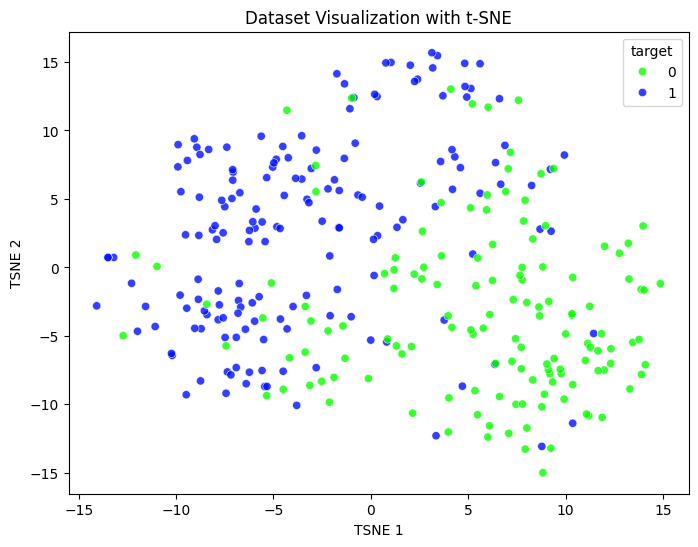

In [6]:
print("\nTSNE Visualization")
# Ми використовуємо на даних після скейлінгу 
tsne = TSNE(n_components=2, random_state=42, perplexity = 35)
X_tsne = tsne.fit_transform(X_scaled)
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE 1', 'TSNE 2'])
tsne_df['target'] = y
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="TSNE 1", y="TSNE 2",
    hue="target",
    palette=sns.color_palette("hsv", 2),
    data=tsne_df,
    legend="full",
    alpha=0.8
)
plt.title('Dataset Visualization with t-SNE')
plt.show()